In [2]:
import pandas as pd

df= pd.read_csv("Teen_Mental_Health_Dataset.csv")
df.head(10)

df.info()
df.describe()
df.isnull().sum()

print(df["gender"].unique())
print(df["platform_usage"].unique())
print(df["social_interaction_level"].unique())

df["gender"] = df["gender"].str.capitalize()
print(df["gender"].unique())

df["social_interaction_level"]= df["social_interaction_level"].str.capitalize()
print(df["social_interaction_level"].unique())
#Erika, veo que no ejecuta bien la orden en "gender", busco solucion y encunetro:

df["gender"]= df["gender"].apply(lambda x: x.capitalize())
print(df["gender"].unique())
# Aprendo a volver a guardar los datos limpios de nuevo en el csv.(Esto es nuevo para mi)

df.to_csv("Teen_Mental_Health_Dataset.csv", index=False)


<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   str    
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   str    
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   str    
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), str(3)
memory usage: 122.0 KB
<StringArray>
['Mal

In [3]:
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,Male,7.9,Instagram,7.4,2.9,3.01,1.5,Low,2,2,1,0
1,19,Female,1.9,TikTok,8.0,2.9,3.22,0.8,High,8,1,10,0
2,17,Female,1.3,Instagram,7.6,0.5,3.92,0.0,High,2,4,2,0
3,15,Male,7.4,TikTok,6.9,1.6,3.48,0.8,Medium,1,7,9,0
4,15,Female,4.7,Both,4.9,3.0,2.37,1.4,Medium,3,5,2,0


In [ ]:
#Vamos a comprobar si tenemos duplicados. 

df.duplicated().sum() #EL resultado nos dice que no hay filas duplicadas, por lo que los datos estan limpios. 

np.int64(0)

In [8]:
#Crear la columna primary key - indice de adolescente. 

adolescente_id = df["adolescente_id"] = range(1, len(df) + 1)
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label,adolescente_id
0,14,Male,7.9,Instagram,7.4,2.9,3.01,1.5,Low,2,2,1,0,1
1,19,Female,1.9,TikTok,8.0,2.9,3.22,0.8,High,8,1,10,0,2
2,17,Female,1.3,Instagram,7.6,0.5,3.92,0.0,High,2,4,2,0,3
3,15,Male,7.4,TikTok,6.9,1.6,3.48,0.8,Medium,1,7,9,0,4
4,15,Female,4.7,Both,4.9,3.0,2.37,1.4,Medium,3,5,2,0,5


In [12]:
#Dividir dataframe en 3 tablas
#1. Tabla adolescente: 

adolescentes = df[['adolescente_id', 'age', 'gender']]
adolescentes

,adolescente_id,age,gender
0,1,14,Male
1,2,19,Female
2,3,17,Female
3,4,15,Male
4,5,15,Female
...,...,...,...
1195,1196,18,Female
1196,1197,16,Male
1197,1198,14,Female
1198,1199,15,Male


In [14]:
#2. Tabla comportamiento_uso:

comportamiento_uso = df[['adolescente_id', 'daily_social_media_hours', 'platform_usage', 'screen_time_before_sleep']]
comportamiento_uso

,adolescente_id,daily_social_media_hours,platform_usage,screen_time_before_sleep
0,1,7.9,Instagram,2.9
1,2,1.9,TikTok,2.9
2,3,1.3,Instagram,0.5
3,4,7.4,TikTok,1.6
4,5,4.7,Both,3.0
...,...,...,...,...
1195,1196,6.8,Instagram,2.0
1196,1197,2.3,Both,1.9
1197,1198,1.7,Both,0.7
1198,1199,3.9,Both,2.1


In [17]:
# Tabla salud_rendimiento:

salud_rendimiento = df[['adolescente_id', 'sleep_hours', 'academic_performance', 'physical_activity', 'social_interaction_level', 'stress_level', 'anxiety_level', 'addiction_level', 'depression_label']]
salud_rendimiento

,adolescente_id,sleep_hours,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,1,7.4,3.01,1.5,Low,2,2,1,0
1,2,8.0,3.22,0.8,High,8,1,10,0
2,3,7.6,3.92,0.0,High,2,4,2,0
3,4,6.9,3.48,0.8,Medium,1,7,9,0
4,5,4.9,2.37,1.4,Medium,3,5,2,0
...,...,...,...,...,...,...,...,...,...
1195,1196,6.6,2.76,1.0,Low,3,4,4,0
1196,1197,8.0,2.12,0.4,High,7,4,4,0
1197,1198,8.7,3.98,0.8,High,1,1,1,0
1198,1199,8.5,3.19,0.6,High,7,9,9,0


In [20]:
#Vamos a crear un archivo csv y guardarlo en la carpeta del proyecto. 

adolescentes.to_csv("adolescentes.csv", index=False)
comportamiento_uso.to_csv("comportamiento_uso.csv", index=False)
salud_rendimiento.to_csv("salud_rendimiento.csv", index=False)

In [21]:
#Vamos a comprobar que se hayan creado en la carpeta del proyecto. 

import os
os.listdir()

['.git',
 'adolescentes.csv',
 'bienestar.csv',
 'comportamiento_uso.csv',
 'Notebook.ipynb',
 'README.md',
 'salud_rendimiento.csv',
 'Teen_Mental_Health_Dataset.csv',
 'uso_redes.csv']

Vamos a conectar Python con MySQL y traer los resultados de SQL a Pandas. 
1. Importar library
2. Crear conection con MySQL
3. Ejecutar query SQL desde Python
4. Guardar resultado en DataFrame
5. Mostrar en Pandas 

In [1]:
pip install pymysql

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd  #Para trabajar con datos
import pymysql    #Para conectarnos a MySQL

In [5]:
connection = pymysql.connect(
    host="localhost",
    user="root",
    password="27021999",
    database="teen_mental_health"
)

In [16]:
#Uso nocturno y plataforma

query = """
SELECT 
    cu.platform_usage,
    ROUND(AVG(cu.screen_time_before_sleep), 2) AS avg_night
FROM comportamiento_uso cu
GROUP BY cu.platform_usage
ORDER BY avg_night DESC;
"""

df_night = pd.read_sql(query, connection)
df_night

C:\Users\pilir\AppData\Local\Temp\ipykernel_1952\30770192.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_night = pd.read_sql(query, connection)


,platform_usage,avg_night
0,TikTok,1.76
1,Both,1.75
2,Instagram,1.71


In [13]:
pip install matplotlib

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ----------- ---------------------------- 2.4/8.3 MB 12.4 MB/s eta 0:00:01
   ----------------------- ---------------- 5.0/8.3 MB 12.7 MB/s eta 0:00:01
   ----------------------------------- ---- 7.3/8.3 MB 11.9 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 11.3 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   -------------------------- ------------- 1.6/2.3 MB 7.4 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 8.2 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ----------- ---------------------------- 2.1/7.2 MB 11.8 MB/s eta 0:00:01
   ----------------------- ---------------- 4.2/7.2 MB 10.5 MB/s eta 0:00:01
   --------------------------------- ------ 6.0/7.2 MB 10.0 MB/s eta 0:00:01
   ---------------------------------------- 7.2/7.2 MB 10.0 MB/s  0:00:00

   ----- ------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


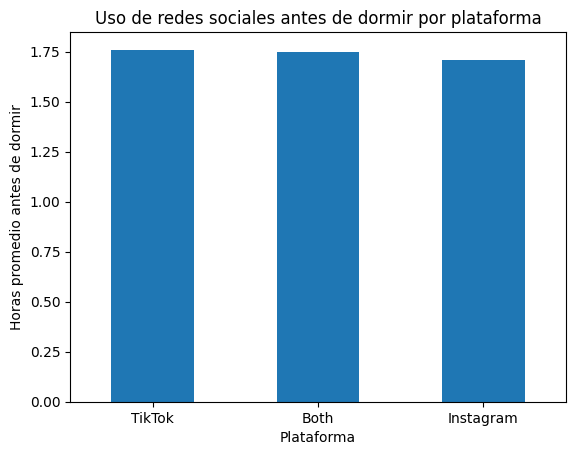

In [17]:
#Crear gráfica

import matplotlib.pyplot as plt

df.plot(
    kind='bar',
    x='platform_usage',
    y='avg_night',
    legend=False
)

plt.title('Uso de redes sociales antes de dormir por plataforma')
plt.xlabel('Plataforma')
plt.ylabel('Horas promedio antes de dormir')
plt.xticks(rotation=0)
plt.show()


In [19]:
#Uso medio diario y plataforma
query = """
SELECT cu.platform_usage,
ROUND(AVG(cu.daily_social_media_hours),2) AS avg_daily
FROM comportamiento_uso AS cu
GROUP BY cu.platform_usage
ORDER BY avg_daily DESC; 
"""
df_daily = pd.read_sql(query,connection)
df_daily


C:\Users\pilir\AppData\Local\Temp\ipykernel_1952\3306134800.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_daily = pd.read_sql(query,connection)


,platform_usage,avg_daily
0,Instagram,4.56
1,TikTok,4.53
2,Both,4.52


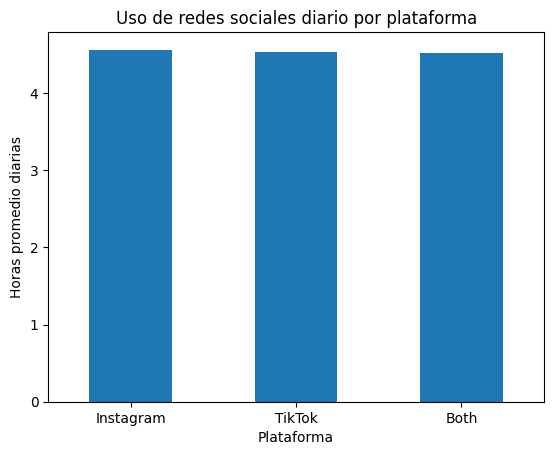

In [21]:
#Crear gráfica

import matplotlib.pyplot as plt

df_daily.plot(
    kind='bar',
    x='platform_usage',
    y='avg_daily',
    legend=False
)

plt.title('Uso de redes sociales diario por plataforma')
plt.xlabel('Plataforma')
plt.ylabel('Horas promedio diarias')
plt.xticks(rotation=0)
plt.show()

In [22]:
#Uso de redes y nivel de estres.
query = """
SELECT 
    CASE 
        WHEN cu.daily_social_media_hours < 3 THEN 'Bajo'
        WHEN cu.daily_social_media_hours BETWEEN 3 AND 5 THEN 'Medio'
        ELSE 'Alto'
    END AS usage_level,
    ROUND(AVG(sr.stress_level), 2) AS avg_stress
FROM comportamiento_uso AS cu
INNER JOIN salud_rendimiento AS sr
    ON cu.adolescente_id = sr.adolescente_id
GROUP BY usage_level
ORDER BY 
    CASE 
        WHEN usage_level = 'Bajo' THEN 1
        WHEN usage_level = 'Medio' THEN 2
        ELSE 3
    END;
"""
df_stress = pd.read_sql(query, connection)
df_stress

C:\Users\pilir\AppData\Local\Temp\ipykernel_1952\2769160925.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_stress = pd.read_sql(query, connection)


,usage_level,avg_stress
0,Bajo,5.50
1,Medio,5.16
2,Alto,5.61


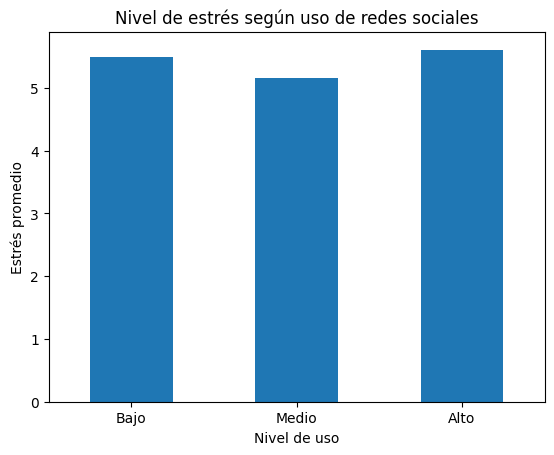

In [23]:
#Crear gráfica

import matplotlib.pyplot as plt

df_stress.plot(
    kind='bar',
    x='usage_level',
    y='avg_stress',
    legend=False
)

plt.title('Nivel de estrés según uso de redes sociales')
plt.xlabel('Nivel de uso')
plt.ylabel('Estrés promedio')
plt.xticks(rotation=0)
plt.show()